# 09 — HMM dynamics for one asset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/09_hmm_dynamics.ipynb)

A Gaussian hidden Markov model puts each day in one of a few regimes, each
with its own mean and volatility, and lets a Markov chain switch between them.
As a dynamics model its residual layer is the Rosenblatt uniform
`v_t = F_t(y_t)`, the predictive mixture evaluated at the observed return,
which is i.i.d. uniform when the model is right; the package takes its normal
score so the C-vine sees the same kind of residual as for a GARCH. A
parametric-bootstrap Cramér-von Mises test on these uniforms is the
goodness-of-fit check, as in GenHMM1d.

Runtime: about 1.5 hours, nearly all of it in the three bootstraps of 100 refits.

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git[garch]"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

from cvinemarketgen import GaussianHMM, load_daily_returns, iid_tests, gof_bootstrap, select_dynamics

cvinemarketgen 0.3.0


## Daily returns of long Treasuries

TLT since 2010, from the cache of notebook 07.

In [2]:
daily = load_daily_returns(["SPY", "TLT", "GLD", "DBC"], start="2010-01-01", cache=os.path.join(ROOT, "data", "daily_cache.csv"))
y = daily["TLT"]
y.describe().round(4)

daily returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/daily_cache.csv: 4197 days, 2010-01-05 to 2026-09-11


count    4197.0000
mean        0.0001
std         0.0094
min        -0.0667
25%        -0.0056
50%         0.0005
75%         0.0057
max         0.0752
Name: TLT, dtype: float64

## Fit two and three regimes

States are sorted by mean. `Q` is the transition matrix; its diagonal is the
probability of staying in a state from one day to the next.

In [3]:
t0 = time.time()
m2 = GaussianHMM(2).fit(y)
m3 = GaussianHMM(3).fit(y)
print(f"fit: {time.time() - t0:.0f} s")

def regimes_table(m):
    return pd.DataFrame({"mean (ann.)": m.mu * 252, "vol (ann.)": m.sigma * np.sqrt(252), "stay prob.": np.diag(m.Q)},
                        index=[f"state {k + 1}" for k in range(m.K)]).round(3)

print(m2.name, f"loglik {m2.loglik:.1f}, BIC {m2.bic:.1f}")
regimes_table(m2)

fit: 58 s
HMM(2) loglik 13918.9, BIC -27787.7


,mean (ann.),vol (ann.),stay prob.
state 1,-0.007,0.210,0.979
state 2,0.053,0.112,0.991


In [4]:
print(m3.name, f"loglik {m3.loglik:.1f}, BIC {m3.bic:.1f}")
regimes_table(m3)

HMM(3) loglik 13994.0, BIC -27887.8


,mean (ann.),vol (ann.),stay prob.
state 1,-0.033,0.169,0.987
state 2,0.057,0.103,0.990
state 3,1.077,0.410,0.953


In [5]:
pd.DataFrame(m2.Q, index=["from state 1", "from state 2"], columns=["to state 1", "to state 2"]).round(4)

,to state 1,to state 2
from state 1,0.9789,0.0211
from state 2,0.0093,0.9907


## Regime probabilities

`regimes` holds the filtered probabilities, `P(state k | returns up to t)`.
State 1 is the lower-mean regime; against the cumulative return of TLT.

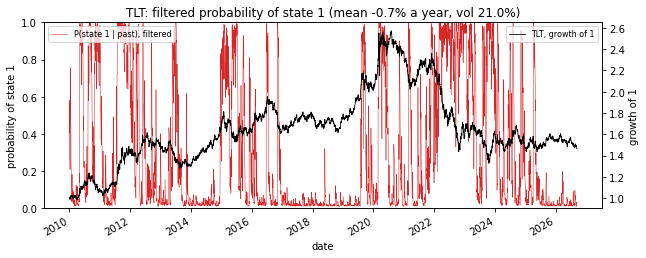

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.8))
m2.regimes["state 1"].plot(ax=ax, lw=0.5, color="tab:red", label="P(state 1 | past), filtered")
ax.set_ylim(0, 1); ax.set_ylabel("probability of state 1")
ax2 = ax.twinx(); (1 + y).cumprod().plot(ax=ax2, color="black", lw=0.8, label="TLT, growth of 1"); ax2.set_ylabel("growth of 1")
ax.set_title(f"TLT: filtered probability of state 1 (mean {m2.mu[0] * 252:+.1%} a year, vol {m2.sigma[0] * np.sqrt(252):.1%})")
ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8); plt.show()

## The residual layer

`filter()` returns the normal scores of the Rosenblatt uniforms. If the model
were right they would be i.i.d. N(0, 1) and the three tests below would not
reject. Read the p-values: the residuals show no autocorrelation, but their
squares do, and the ARCH-LM test rejects. Two regimes with constant
volatility inside each do not absorb the volatility clustering of daily
Treasury returns; this is what the selector will hold against the HMM.

In [7]:
z = m2.filter()
pd.Series(iid_tests(z.values), name="p-value").round(3)

lb_z       0.133
lb_z2      0.000
arch_lm    0.000
Name: p-value, dtype: float64

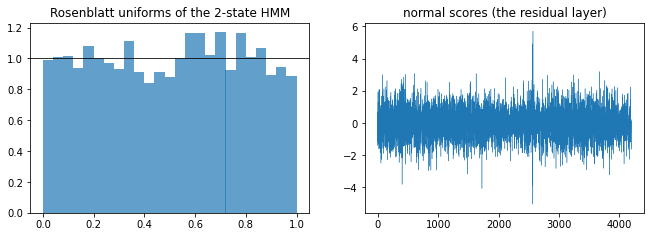

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(m2.uniforms(), bins=25, density=True, color="tab:blue", alpha=0.7); axes[0].axhline(1, color="black", lw=0.8); axes[0].set_title("Rosenblatt uniforms of the 2-state HMM")
axes[1].plot(z.values, lw=0.4); axes[1].set_title("normal scores (the residual layer)"); plt.show()

## The bootstrap goodness-of-fit test

The Cramér-von Mises statistic of the uniforms against the uniform distribution,
compared with its distribution under the fitted model: 100 series are simulated
from the model, each is refitted, and the statistic is recomputed. The p-value
is the share of bootstrap statistics above the observed one. Both models are
rejected here: with 4,197 days, the test has the power to see the clustering
the residual tests found above.

In [9]:
t0 = time.time()
g2 = gof_bootstrap(m2, y, B=100, seed=0)
g3 = gof_bootstrap(m3, y, B=100, seed=0)
print(f"{time.time() - t0:.0f} s")
pd.DataFrame({"CvM statistic": [g2["stat"], g3["stat"]], "bootstrap p-value": [g2["pvalue"], g3["pvalue"]], "BIC": [m2.bic, m3.bic]},
             index=[m2.name, m3.name]).round(4)

4679 s


,CvM statistic,bootstrap p-value,BIC
HMM(2),0.2023,0.0,-27787.7229
HMM(3),0.2638,0.0,-27887.8005


## Against the GARCH family

`select_dynamics` runs the whole competition for this asset: the 28
candidates, the i.i.d. tests, BIC among the ones that pass, the bootstrap on
the winner. For TLT the HMM candidates fail the ARCH tests and a
Const-GARCH(1,1) wins; its own bootstrap p-value is 0 too, because Gaussian
innovations cannot carry the fat tails of the standardized residuals. The
generator does not rely on that assumption: the Johnson SU marginal of the
residual layer is fitted to the residuals' skewness and kurtosis.

In [10]:
t0 = time.time()
ad = select_dynamics(y.to_frame(), gof=True, B=100, seed=0, verbose=False)
print(f"{time.time() - t0:.0f} s")
ad.report.T

78 s


asset,TLT
model,"Const-GARCH(1,1)"
mean,const
vol,garch
p,1
q,1
states,0
n_params,4
loglik,13984.604841
bic,-27935.841181
lb_z,0.269842


In [11]:
c = ad.candidates
c.sort_values("bic")[["model", "n_params", "bic", "lb_z", "lb_z2", "arch_lm", "passed"]].head(8).round(3)

,model,n_params,bic,lb_z,lb_z2,arch_lm,passed
2,"Const-GARCH(1,1)",4,-27935.841,0.270,0.850,0.881,True
18,"Const-EGARCH(1,1)",4,-27930.555,0.260,0.342,0.431,True
10,"Const-GJR(1,1)",5,-27930.407,0.269,0.932,0.945,True
3,"Const-GARCH(1,2)",5,-27928.544,0.269,0.855,0.881,True
6,"AR(1)-GARCH(1,1)",5,-27927.632,0.594,0.855,0.885,True
4,"Const-GARCH(2,1)",5,-27927.499,0.270,0.850,0.881,True
20,"Const-EGARCH(2,1)",5,-27923.955,0.255,0.309,0.389,True
19,"Const-EGARCH(1,2)",5,-27923.161,0.258,0.333,0.415,True


## A simulated year

`unfilter` maps i.i.d. normal scores back to returns: at each day the uniform
is inverted through the predictive mixture, then the regime probabilities are
updated with the simulated return. Five paths after the last observed day.

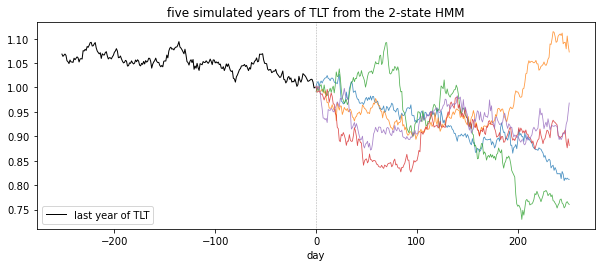

In [12]:
paths = m2.unfilter(np.random.default_rng(1).standard_normal((5, 252)))
hist = (1 + y.iloc[-252:]).cumprod()
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(np.arange(-252, 0), hist.values / hist.values[-1], color="black", lw=1, label="last year of TLT")
for k in range(5):
    ax.plot(np.arange(0, 252), np.cumprod(1 + paths[k]), lw=0.8, alpha=0.8)
ax.axvline(0, color="grey", lw=0.6, ls=":"); ax.set_xlabel("day"); ax.set_title("five simulated years of TLT from the 2-state HMM"); ax.legend(); plt.show()

## In a market

In `CVineMarket(..., dynamics='auto')` this model is one candidate per asset,
next to the GARCH family; `dynamics={'TLT': 'hmm(2)', ...}` imposes it. Notebook
07 runs the selection for four ETFs (the HMM with three regimes wins for the
commodity ETF) and simulates the paths.